# **CHAPTER 4 Training Models**


The Normal Equation:

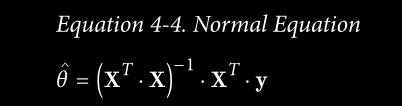

In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

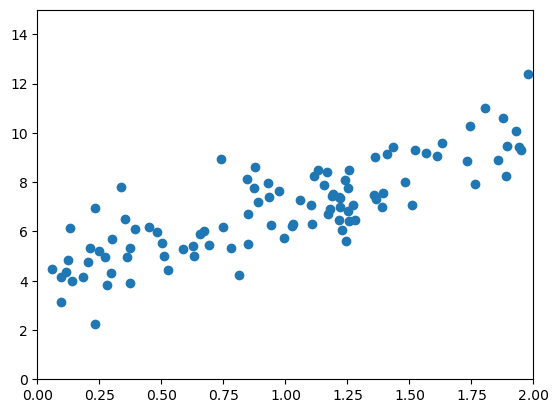

In [2]:
plt.scatter(X, y)
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
len(X)

100

In [4]:
X_b = np.c_[np.ones((100, 1)), X]
X_b.T

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.  

In [5]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [6]:
theta_best

array([[4.10188526],
       [2.86820836]])

In [7]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]

print(X_new)
print(X_new_b)

[[0]
 [2]]
[[1. 0.]
 [1. 2.]]


In [8]:
y_pred = X_new_b.dot(theta_best)
y_pred

array([[4.10188526],
       [9.83830197]])

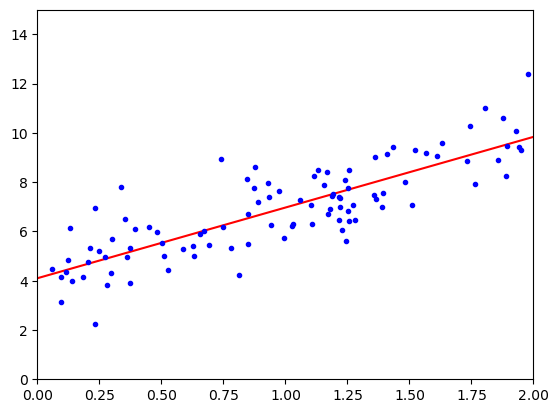

In [9]:
plt.plot(X_new, y_pred, "r-")
plt.plot(X, y, 'b.' )
plt.axis([0, 2, 0, 15])
plt.show()

using sklearn library

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X, y)

print(lr.intercept_, lr.coef_)
print(lr.predict(X_new))
 

[4.10188526] [[2.86820836]]
[[4.10188526]
 [9.83830197]]


**Computational Complexity**

(X^T . X) . inv(X) -> n^3 for Normal Equation

# **Gradient Descent**

In [11]:
lr = 0.1 
n_iterations = 1000
m = 100

theta =np.random.randn(2,1)

for iteration in range(n_iterations):
    gradient_descent = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - lr * gradient_descent

print(theta)

[[4.10188526]
 [2.86820836]]


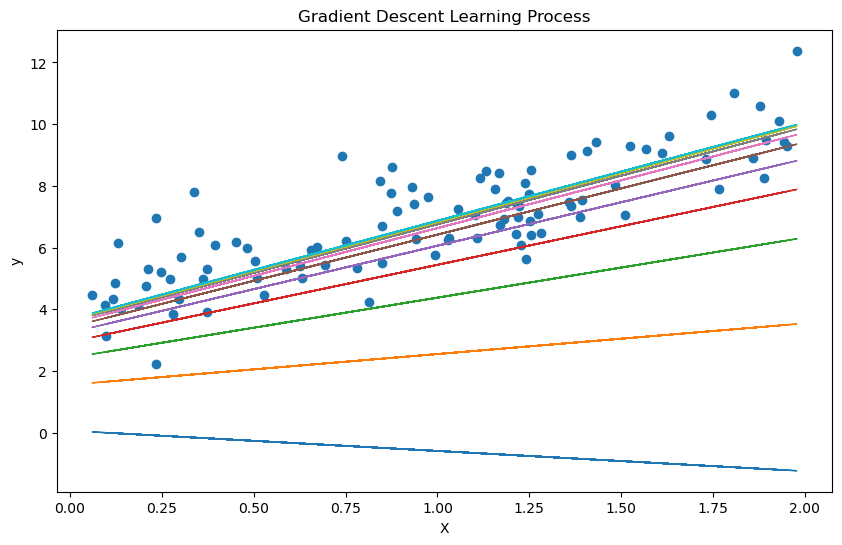

In [12]:
theta = np.random.randn(2,1)

theta_history_batch = []

learning_rate = 0.1
n_iterations = 200
m = len(X_b)

plt.figure(figsize=(10,6))

plt.scatter(X, y)

for iteration in range(n_iterations):

    y_predict = X_b.dot(theta)
    if iteration < 10:
        plt.plot(X, y_predict, linewidth=1)
        
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients
    
    theta_history_batch.append(theta.copy()) 
    
theta_history_batch = np.array(theta_history_batch).squeeze()


plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent Learning Process")
plt.show()

In [13]:
theta

array([[4.10002998],
       [2.86985694]])

# **Stochastic Gradient Descent**

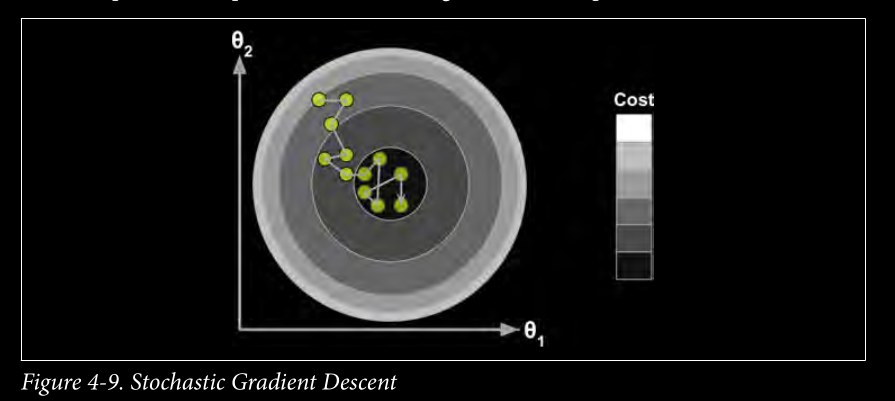

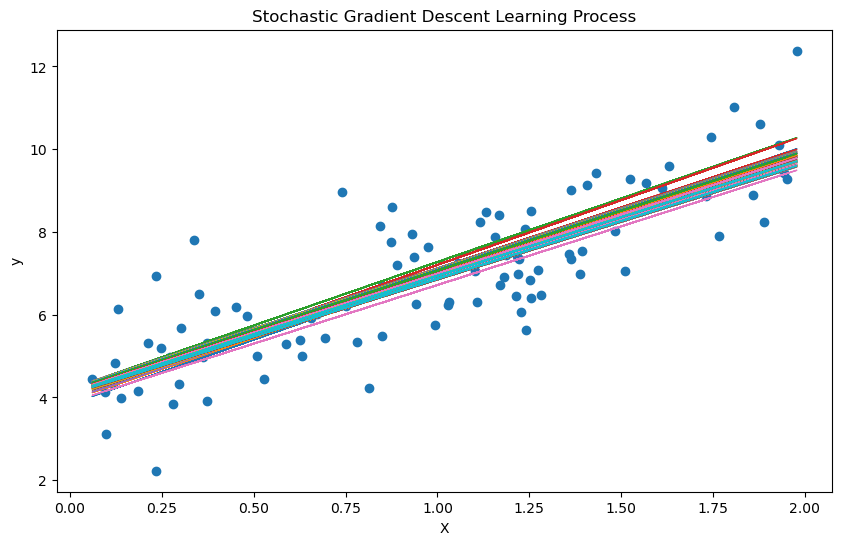

In [14]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters
theta_history_SGD = []

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)

plt.figure(figsize=(10,6))
plt.scatter(X, y)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
                
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        
        eta = learning_schedule(epoch * m + i)
        
        theta = theta - eta * gradients

        theta_history_SGD.append(theta.copy())
    y_predict = X_b.dot(theta)
    plt.plot(X, y_predict, linewidth=1)

theta_history_SGD = np.array(theta_history_SGD).squeeze()

plt.xlabel("X")
plt.ylabel("y")
plt.title("Stochastic Gradient Descent Learning Process")
plt.show()


In [15]:
theta

array([[4.11229875],
       [2.83040116]])

In [16]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=50, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, max_iter=50, penalty=None)

In [17]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.03623074]), array([2.84706637]))

# **Mini-batch Gradient Descent**

12


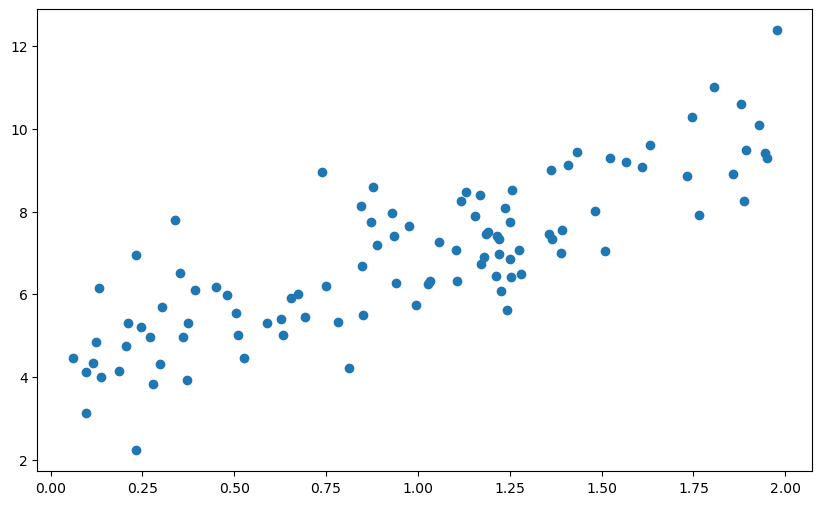

In [18]:
batch_size = 8
n_iterations_per_epoch = m // batch_size
print(n_iterations_per_epoch)

plt.figure(figsize=(10,6))
plt.scatter(X, y)

for epoch in range(n_epochs):
    indices = np.random.permutation(m)
    for j in range(0, m, batch_size):
        batch_idx = indices[j:j+batch_size]
        xi = X_b[batch_idx]
        yi = y[batch_idx]
        gradients = 2/len(batch_idx) * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * n_iterations_per_epoch + j//batch_size)
        theta -= eta * gradients
        


**Divergence**

This is the dangerous one.
It happens when learning rate is TOO LARGE.

Example: η=10

```
What Happens?

Updates overshoot the minimum.

Instead of approaching minimum:

jump left
jump right
jump farther away

until values explode.
```


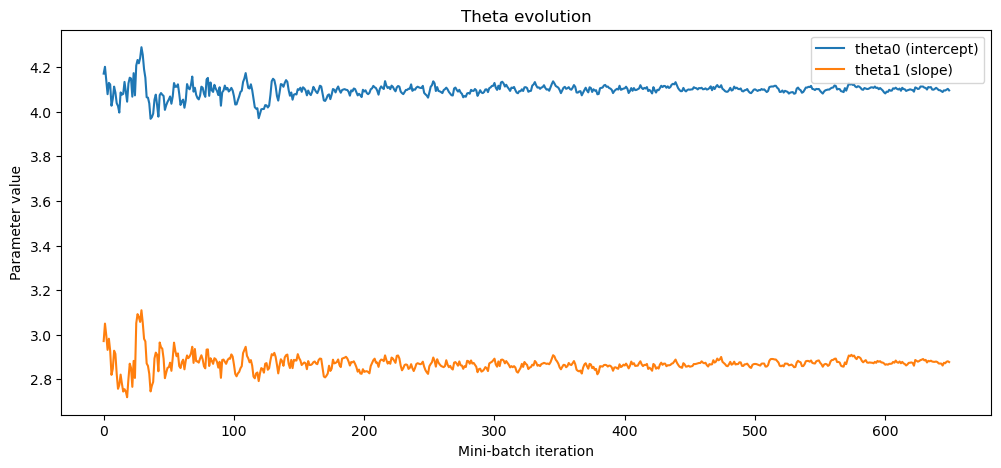

In [19]:
theta_history_Mini_SGD = []

for epoch in range(n_epochs):
    indices = np.random.permutation(m)
    for j in range(0, m, batch_size):
        batch_idx = indices[j:j+batch_size]
        xi = X_b[batch_idx]
        yi = y[batch_idx]
        gradients = 2/len(batch_idx) * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * n_iterations_per_epoch + j//batch_size)
        theta -= eta * gradients
        
        theta_history_Mini_SGD.append(theta.copy())

# After training, plot theta0 and theta1 over iterations
theta_history_Mini_SGD = np.array(theta_history_Mini_SGD).squeeze()  # shape (n_updates, 2)

plt.figure(figsize=(12,5))
plt.plot(theta_history_Mini_SGD[:,0], label='theta0 (intercept)')
plt.plot(theta_history_Mini_SGD[:,1], label='theta1 (slope)')
plt.xlabel('Mini-batch iteration')
plt.ylabel('Parameter value')
plt.legend()
plt.title('Theta evolution')
plt.show()

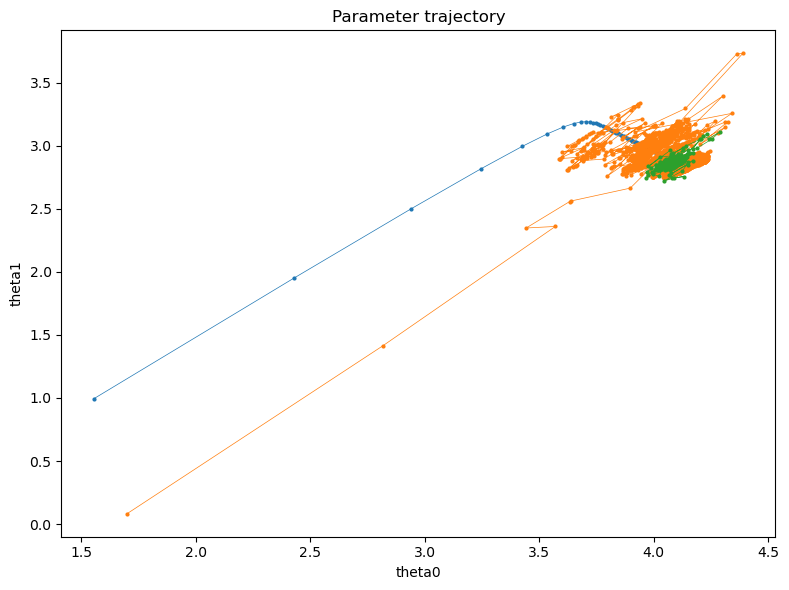

In [ ]:
# plt.figure(figsize=(8,6))
# plt.plot(theta_history_batch[:,0],theta_history_batch[:,1],  'o-', markersize=2, linewidth=0.5, label='Batch')
# plt.plot(theta_history_SGD[:,0],theta_history_SGD[:,1], 'o-', markersize=2, linewidth=0.5, label='SGD')
# plt.plot(theta_history_Mini_SGD[:,0], theta_history_Mini_SGD[:,1], 'o-', markersize=2, linewidth=0.5, label='MSGD')
# plt.xlabel('theta0')
# plt.ylabel('theta1')
# plt.title('Parameter trajectory')
# plt.tight_layout()
# plt.show()

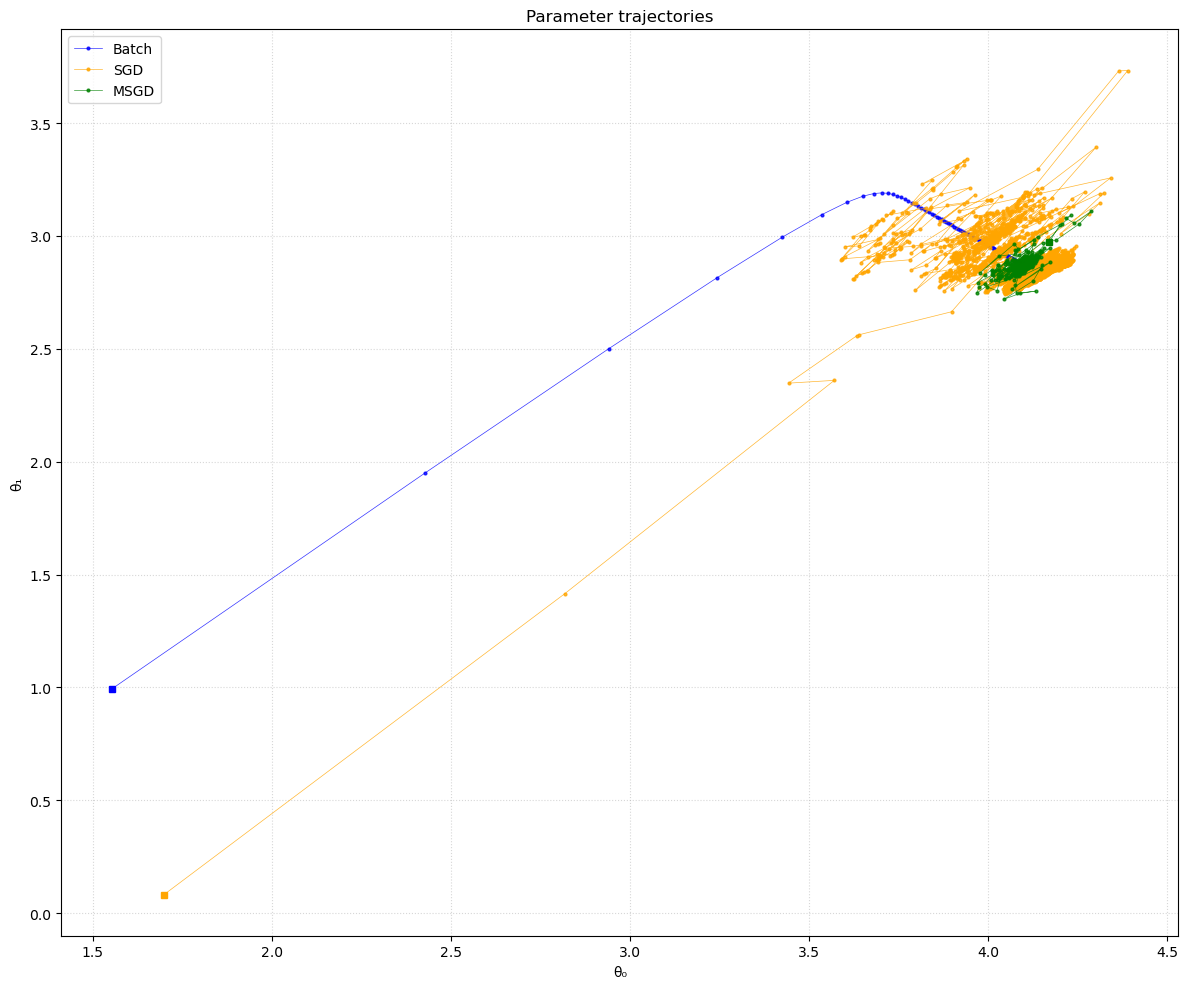

In [21]:
plt.figure(figsize=(12,10))

for hist, label, color in zip(
    [theta_history_batch, theta_history_SGD, theta_history_Mini_SGD],
    ['Batch', 'SGD', 'MSGD'],
    ['blue', 'orange', 'green']
):
    if hist is not None and len(hist) > 0:
        plt.plot(hist[:,0], hist[:,1], 'o-', markersize=2, linewidth=0.5,
                 color=color, label=label, alpha=0.8)
        # mark starting point
        plt.plot(hist[0,0], hist[0,1], 's', color=color, markersize=4)
        # mark end point
        plt.plot(hist[-1,0], hist[-1,1], '*', color=color, markersize=6)

plt.xlabel('θ₀')
plt.ylabel('θ₁')
plt.title('Parameter trajectories')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## **Comparison of algorithms for Linear Regression**
| Algorithm | Large \(m\) | Out‑of‑core support | Large \(n\) | Hyperparams | Scaling required | Scikit‑Learn |
|-----------|-------------|----------------------|-------------|-------------|------------------|---------------|
| **Normal Equation** | Fast* (if \(n\) small) | No | Slow (\(O(n^3)\)) | 0 | No | `LinearRegression` |
| **Batch GD** | Slow (one epoch = O(m n)) | No | Fast (iterations scale with n) | ≥2 (lr, epochs) | Yes | n/a (no direct batch GD; use `SGDRegressor` with batch size = m via `partial_fit` manually) |
| **Stochastic GD** | Fast (per‑sample updates) | Yes | Fast | ≥2 (lr, epochs, …) | Yes | `SGDRegressor` |
| **Mini‑batch GD** | Fast (per‑batch updates) | Yes | Fast | ≥3 (lr, batch size, epochs) | Yes | `SGDRegressor` (set `batch_size`; default mini‑batch) |


# **Polynomial Regression**

In [94]:
m = 300
X = 6 * np.random.rand(m, 1) - 3
# y = ax2 + bx + c.
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

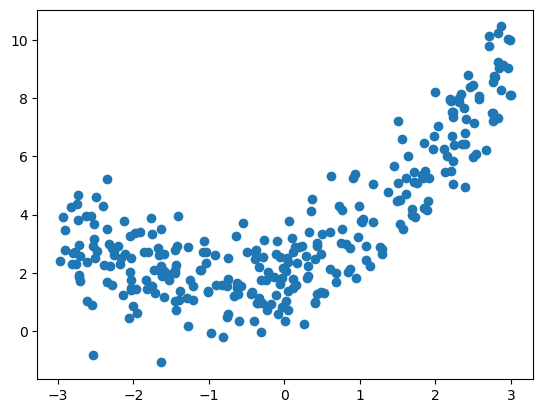

In [95]:
plt.scatter(X, y)
plt.show()

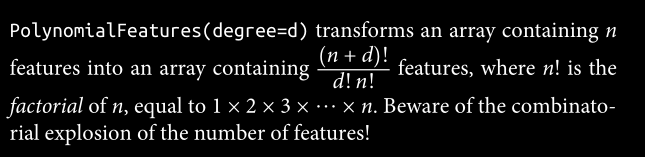

In [96]:
from sklearn.preprocessing import PolynomialFeatures
plyf = PolynomialFeatures(degree=25, include_bias=False)
X_poly = plyf.fit_transform(X)
X[0]

array([0.04581353])

In [97]:
X_poly[0]

array([4.58135272e-02, 2.09887927e-03, 9.61570626e-05, 4.40529420e-06,
       2.01822066e-07, 9.24618069e-09, 4.23600150e-10, 1.94066170e-11,
       8.89085576e-13, 4.07321462e-14, 1.86608329e-15, 8.54918574e-17,
       3.91668353e-18, 1.79437087e-19, 8.22064588e-21, 3.76616784e-22,
       1.72541433e-23, 7.90473161e-25, 3.62143636e-26, 1.65910773e-27,
       7.60095772e-29, 3.48226683e-30, 1.59534926e-31, 7.30885768e-33,
       3.34844550e-34])

In [98]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_poly, y)
print(lr.intercept_, lr.coef_)

[1.87806121] [[ 1.50543710e+00  1.72131005e+00 -6.64458325e+00 -4.51073059e+00
   2.81197641e+01  9.59304339e+00 -5.36319697e+01 -1.19816477e+01
   5.47985025e+01  9.06173474e+00 -3.35499796e+01 -4.30130660e+00
   1.31347917e+01  1.31832960e+00 -3.40362003e+00 -2.64357708e-01
   5.90542803e-01  3.44256848e-02 -6.78564127e-02 -2.80352359e-03
   4.95462618e-03  1.29684333e-04 -2.08161602e-04 -2.60096300e-06
   3.83151804e-06]]


In [99]:
X_smooth = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_smooth_poly = plyf.transform(X_smooth)
y_smooth = lr.predict(X_smooth_poly)

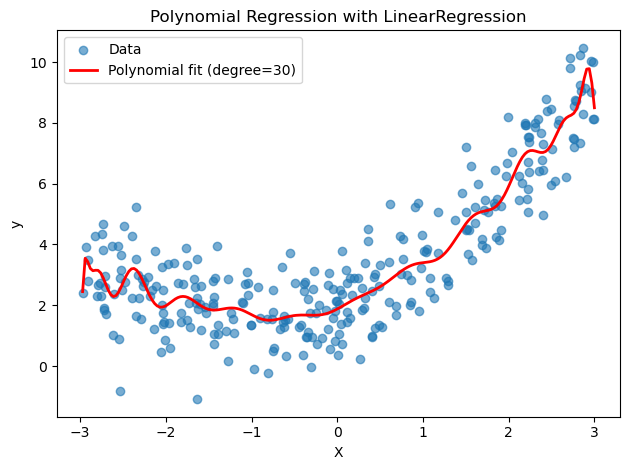

In [100]:
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_smooth, y_smooth, 'r-', linewidth=2, label='Polynomial fit (degree=30)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression with LinearRegression')
plt.legend()
plt.tight_layout()
plt.show()

# **Learning Curves**

you used cross-validation to get an estimate of a model’s generalization
performance, 

**Another way is learning curves: these are plots of the model’s perfor‐
mance on the training set and the validation set as a function of the training set size.**

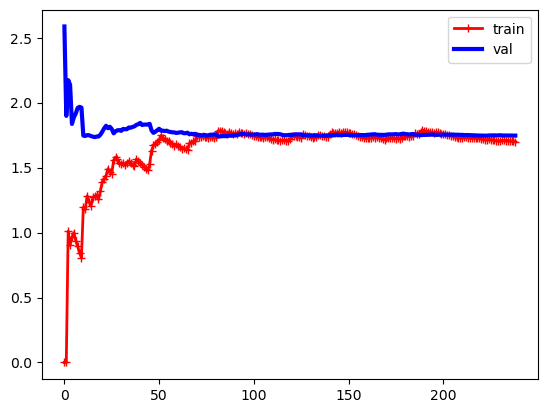

In [101]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42)

    training_errors = [] 
    val_errors = []
    
    for m in range(1, len(X_train)):
        
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_val_pred = model.predict(X_val)
        
        training_errors.append(mean_squared_error(y_train_pred, y_train[:m]))       
        val_errors.append(mean_squared_error(y_val_pred, y_val))
        
    plt.plot(np.sqrt(training_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend()
    plt.show()


lr = LinearRegression()
plot_learning_curves(lr, X, y)


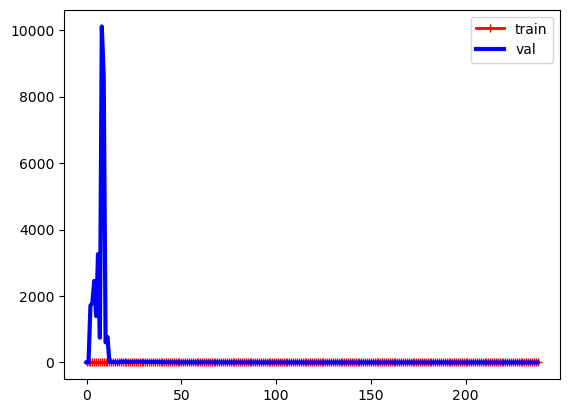

In [102]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline((
("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
("sgd_reg", LinearRegression()),
))

plot_learning_curves(polynomial_regression, X, y)

In [103]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])


array([[5.03704535]])

In [104]:

# And using Stochastic Gradient Descent:14
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.99943401])